# YouTube Comment Sentiment Analysis Using SVM

This notebook builds a basic Support Vector Machine (SVM) model from start to finish using `YoutubeCommentsDataSet.csv`.

Workflow covered:
- Load dataset
- EDA
- Outlier detection and removal
- Feature scaling
- SVM model training
- Accuracy evaluation



In [10]:
import warnings
warnings.filterwarnings('ignore')

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [11]:
# 1. LOAD DATASET
df = pd.read_csv('YoutubeCommentsDataSet.csv')

print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())
print('\nMissing values:')
display(df.isnull().sum())

Dataset shape: (18408, 2)
Columns: ['Comment', 'Sentiment']


,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive



Missing values:


Comment      44
Sentiment     0
dtype: int64

In [12]:
# 2. DATA CLEANING
df = df.dropna(subset=['Comment']).copy()
df['Comment'] = df['Comment'].astype(str).str.strip()
df = df[df['Comment'] != ''].copy()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\\S+|www\\S+', ' ', text)
    text = re.sub(r'[^a-z\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

df['clean_comment'] = df['Comment'].apply(clean_text)
df = df[df['clean_comment'] != ''].copy()
df['comment_length'] = df['clean_comment'].str.len()
df['word_count'] = df['clean_comment'].str.split().str.len()

print('Shape after cleaning:', df.shape)
display(df[['Comment', 'clean_comment', 'Sentiment']].head())

Shape after cleaning: (18140, 5)


,Comment,clean_comment,Sentiment
0,lets not forget that apple pay in 2014 require...,lets not forget that apple pay in require...,neutral
1,here in nz 50 of retailers don’t even have con...,here in nz of retailers don t even have con...,negative
2,i will forever acknowledge this channel with t...,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,whenever i go to a place that doesn t take app...,negative
4,apple pay is so convenient secure and easy to ...,apple pay is so convenient secure and easy to ...,positive


Sentiment distribution:


Sentiment
positive    11383
neutral      4422
negative     2335
Name: count, dtype: int64

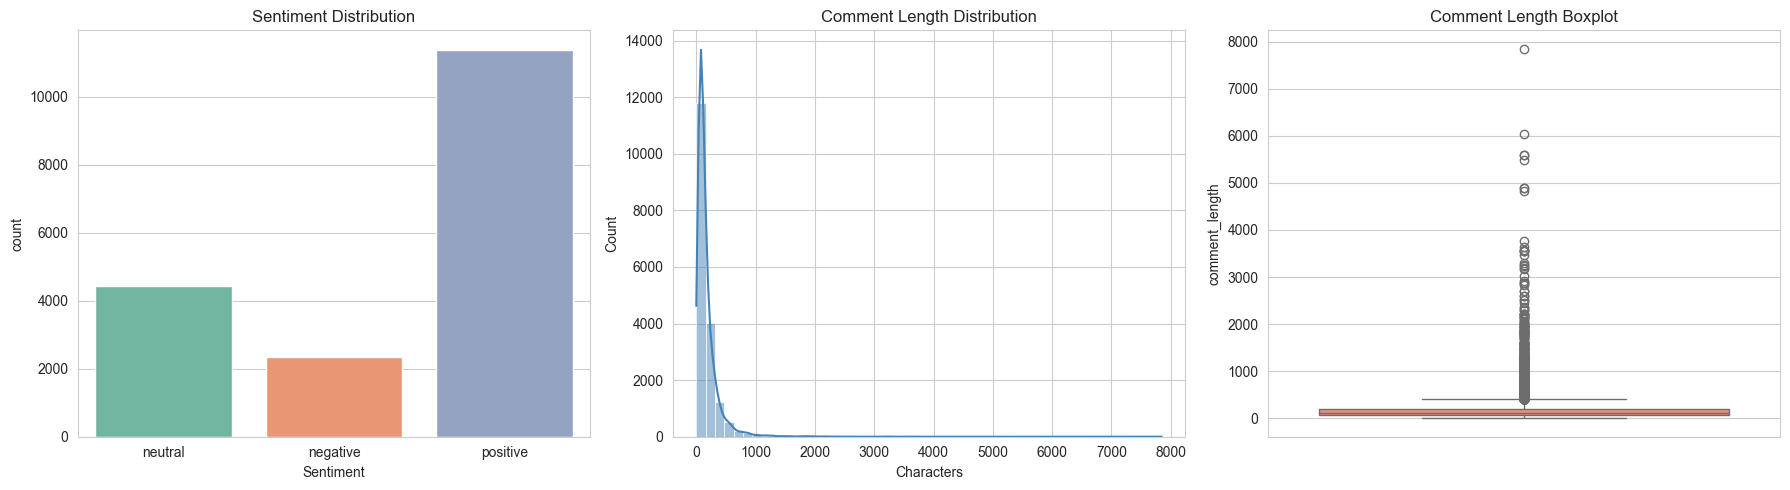

Comment length summary:


count    18140.000000
mean       178.406340
std        252.194328
min          1.000000
25%         67.000000
50%        113.000000
75%        203.000000
max       7847.000000
Name: comment_length, dtype: float64

In [13]:
# 3. EDA
print('Sentiment distribution:')
display(df['Sentiment'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Sentiment Distribution')

sns.histplot(df['comment_length'], bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('Comment Length Distribution')
axes[1].set_xlabel('Characters')

sns.boxplot(y=df['comment_length'], color='salmon', ax=axes[2])
axes[2].set_title('Comment Length Boxplot')

plt.tight_layout()
plt.show()

print('Comment length summary:')
display(df['comment_length'].describe())

Lower bound: 1.00
Upper bound: 407.00
Outliers found: 1416
Shape before outlier removal: (18140, 5)
Shape after outlier removal: (16724, 5)


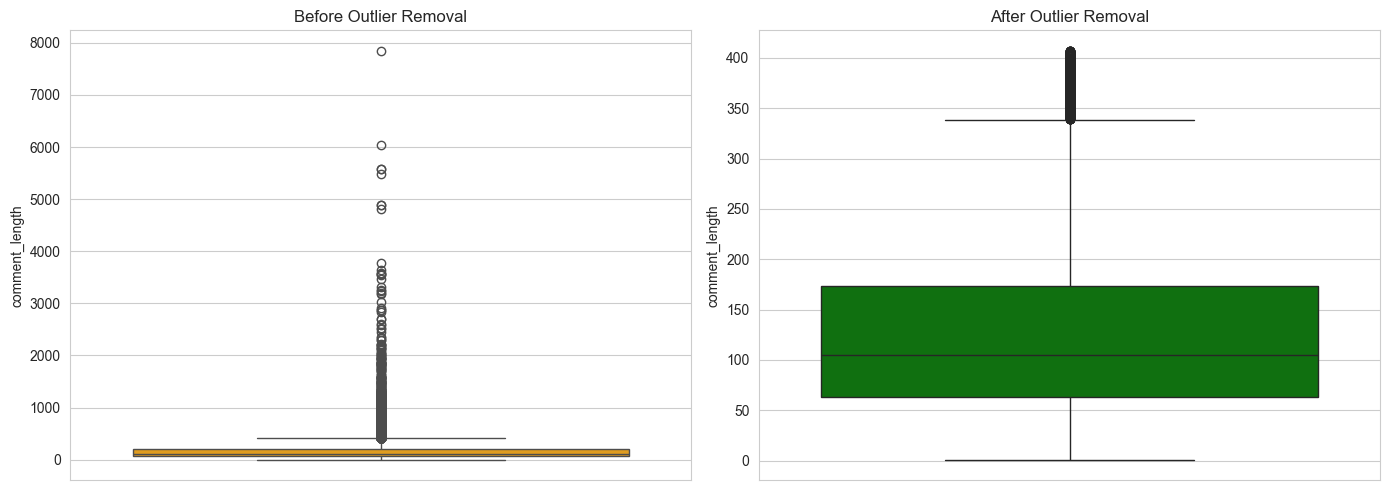

In [14]:
# 4. OUTLIER DETECTION AND REMOVAL USING IQR
Q1 = df['comment_length'].quantile(0.25)
Q3 = df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(1, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['comment_length'] < lower_bound) | (df['comment_length'] > upper_bound)]
df_no_outliers = df[(df['comment_length'] >= lower_bound) & (df['comment_length'] <= upper_bound)].copy()

print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')
print('Outliers found:', len(outliers))
print('Shape before outlier removal:', df.shape)
print('Shape after outlier removal:', df_no_outliers.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['comment_length'], color='orange', ax=axes[0])
axes[0].set_title('Before Outlier Removal')
sns.boxplot(y=df_no_outliers['comment_length'], color='green', ax=axes[1])
axes[1].set_title('After Outlier Removal')
plt.tight_layout()
plt.show()

In [15]:
binary_df = df_no_outliers[df_no_outliers['Sentiment'].isin(['positive', 'negative'])].copy()

print('Binary dataset shape:', binary_df.shape)
display(binary_df['Sentiment'].value_counts())

X = binary_df['clean_comment']
y = binary_df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Binary dataset shape: (12793, 5)


Sentiment
positive    10712
negative     2081
Name: count, dtype: int64

Training samples: 10234
Testing samples: 2559


In [16]:
# 6. FEATURE SCALING + SVM MODEL TRAINING
# TF-IDF converts text into numeric features.
# MaxAbsScaler is used because TF-IDF creates sparse features.

svm_model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('scaler', MaxAbsScaler()),
    ('svm', LinearSVC(C=0.5, max_iter=5000, random_state=42))
])

svm_model.fit(X_train, y_train)
print('SVM model trained successfully.')

SVM model trained successfully.


SVM Accuracy: 0.8972
SVM Accuracy Percentage: 89.72%

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.57      0.65       416
    positive       0.92      0.96      0.94      2143

    accuracy                           0.90      2559
   macro avg       0.83      0.77      0.79      2559
weighted avg       0.89      0.90      0.89      2559



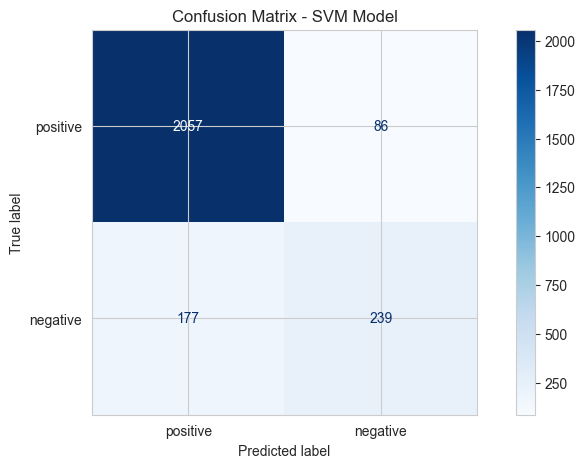

In [17]:
# 7. MODEL ACCURACY AND EVALUATION
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'SVM Accuracy: {accuracy:.4f}')
print(f'SVM Accuracy Percentage: {accuracy * 100:.2f}%')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['positive', 'negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - SVM Model')
plt.show()

In [18]:
# 8. SAMPLE PREDICTIONS
sample_comments = [
    'This video is amazing and very helpful',
    'I hate this update, it is so bad',
    'Excellent explanation and great content',
    'Worst thing I watched today'
]

sample_predictions = svm_model.predict(sample_comments)

for comment, pred in zip(sample_comments, sample_predictions):
    print('Comment:', comment)
    print('Predicted sentiment:', pred)
    print('-' * 60)

Comment: This video is amazing and very helpful
Predicted sentiment: positive
------------------------------------------------------------
Comment: I hate this update, it is so bad
Predicted sentiment: negative
------------------------------------------------------------
Comment: Excellent explanation and great content
Predicted sentiment: positive
------------------------------------------------------------
Comment: Worst thing I watched today
Predicted sentiment: negative
------------------------------------------------------------
